# 02 – Exploratory Data Analysis & Feature Engineering (M2)
**IT3051 Fundamentals of Data Mining – Mini Project 2026**
**Task:** Regression – predict **`Days for shipping (real)`** at order placement.
**Owner:** M2 (EDA & Features)

### What this notebook does
1. Explores the **training set only** – structure, missing values, the target, relationships, correlation, outliers, time patterns.
2. Creates the **date features** from the order timestamp: weekday, month, hour, quarter, is_weekend.
3. Saves train and test files with the new features for M3 and M4.

### Golden rule
All EDA uses the **training set only**. If we explored the test set, our decisions would be influenced by it and the final test
score would no longer be honest. The test set is touched once (Step 9) – only to add the same date features.

### Input and output
| Input (from M1) | Output (for M3, M4) |
|---|---|
| `data/processed/train_reg.csv`, `test_reg.csv` | `data/processed/train_fe.csv`, `test_fe.csv` + charts in `reports/figures/m2/` |

## Step 0 – Setup
`show()` saves every chart as a numbered PNG (for the report and slides) and displays it.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED_DIR = ROOT / "data" / "processed"
FIG_DIR = ROOT / "reports" / "figures" / "m2"
FIG_DIR.mkdir(parents=True, exist_ok=True)

TARGET = "Days for shipping (real)"
GROUP = "Order Id"
DATE_COL = "order date (DateOrders)"
DATE_FMT = "%m/%d/%Y %H:%M"

def show(fig, name):
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"{name}.png", dpi=120)
    plt.show()

## Step 1 – Load the training data
`order_dt` is the order date converted to a real date – used only for the time charts in this notebook.

In [2]:
train = pd.read_csv(PROCESSED_DIR / "train_reg.csv")
train["order_dt"] = pd.to_datetime(train[DATE_COL], format=DATE_FMT)
y = train[TARGET]
print(f"Train: {train.shape[0]:,} rows, {train[GROUP].nunique():,} orders")

Train: 138,098 rows, 50,318 orders


## Step 2 – Structure of the data
### 2.1 Variable types and number of values
The number of different values decides the encoding later: few values → one-hot; many values (e.g. Order Country, Order City) → special encoding (M3).

In [3]:
NUMERIC = [c for c in train.select_dtypes("number").columns if c not in (TARGET, GROUP)]
CATEGORICAL = [c for c in train.select_dtypes(exclude="number").columns if c not in (DATE_COL, "order_dt")]

structure = pd.DataFrame({
    "type": ["numeric"] * len(NUMERIC) + ["categorical"] * len(CATEGORICAL),
    "n_unique": [train[c].nunique() for c in NUMERIC + CATEGORICAL],
    "example": [train[c].iloc[0] for c in NUMERIC + CATEGORICAL],
}, index=NUMERIC + CATEGORICAL)
structure

,type,n_unique,example
Benefit per order,numeric,20092,91.25
Sales per customer,numeric,2834,314.640015
Category Id,numeric,51,73
Latitude,numeric,10480,18.251453
Longitude,numeric,4411,-66.037056
Order Item Discount,numeric,985,13.11
Order Item Discount Rate,numeric,18,0.04
Order Item Profit Ratio,numeric,162,0.29
Order Item Quantity,numeric,5,1
Sales,numeric,193,327.75


### 2.2 Summary statistics of numeric columns
Look for negative minimums (losses in profit columns) and long right tails (max much larger than the 75th percentile).

In [4]:
train[NUMERIC].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Benefit per order,138098.0,22.17,103.76,-4274.98,7.14,31.67,64.89,911.80
Sales per customer,138098.0,183.29,119.97,7.49,104.38,163.99,247.50,1939.99
Category Id,138098.0,31.86,15.65,2.00,18.00,29.00,45.00,76.00
Latitude,138098.0,29.72,9.82,-33.94,18.27,33.15,39.28,48.78
Longitude,138098.0,-84.84,21.47,-158.03,-98.30,-76.77,-66.37,115.26
Order Item Discount,138098.0,20.67,21.88,0.00,5.40,14.00,30.00,500.00
Order Item Discount Rate,138098.0,0.10,0.07,0.00,0.04,0.09,0.16,0.25
Order Item Profit Ratio,138098.0,0.12,0.47,-2.75,0.08,0.27,0.36,0.50
Order Item Quantity,138098.0,2.13,1.45,1.00,1.00,1.00,3.00,5.00
Sales,138098.0,203.96,132.29,9.99,119.98,199.92,299.95,1999.99


## Step 3 – Missing values and duplicates
M1 already dropped the empty columns, so nothing should be missing. Orders repeat across rows because each row is one **item** –
that is not duplication, and it is why the split is grouped by Order Id.

In [5]:
missing = train.isna().sum()
print("Columns with missing values:", missing[missing > 0].to_dict() or "none")
print("Exact duplicate rows:", train.duplicated().sum())
items = train.groupby(GROUP).size()
print(f"Rows per order: mean {items.mean():.2f}, max {items.max()}, orders with >1 item {(items > 1).mean() * 100:.1f}%")

Columns with missing values: none
Exact duplicate rows: 0
Rows per order: mean 2.74, max 5, orders with >1 item 69.7%


## Step 4 – The target
### 4.1 Distribution of real shipping days
Skewness close to 0 means no long tail, so the target needs no log transformation.

count    138098.00
mean          3.50
std           1.63
min           0.00
25%           2.00
50%           3.00
75%           5.00
max           6.00
Name: Days for shipping (real), dtype: float64
Skewness: 0.09


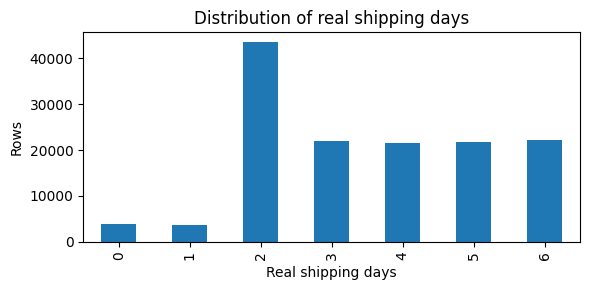

In [6]:
print(y.describe().round(2))
print(f"Skewness: {y.skew():.2f}")
fig, ax = plt.subplots(figsize=(6, 3))
y.value_counts().sort_index().plot.bar(ax=ax)
ax.set_xlabel("Real shipping days"); ax.set_ylabel("Rows"); ax.set_title("Distribution of real shipping days")
show(fig, "01_target_distribution")

### 4.2 Shipping days by shipping mode
The difference **between** modes is what Shipping Mode explains. The spread **within** each mode (error bars) is what the other features must explain.

                mean   std  min  max  count
Shipping Mode                              
Same Day        0.49  0.50    0    1   7431
First Class     2.00  0.00    2    2  21201
Second Class    3.99  1.42    2    6  26922
Standard Class  4.00  1.42    2    6  82544


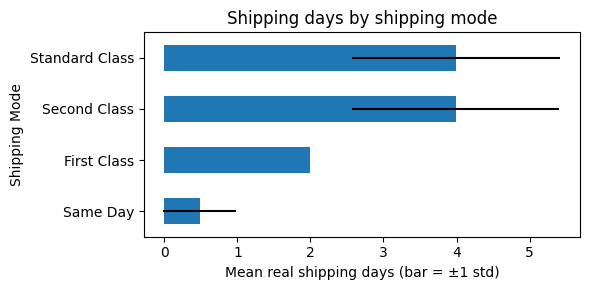

In [7]:
by_mode = y.groupby(train["Shipping Mode"]).agg(["mean", "std", "min", "max", "count"]).sort_values("mean")
print(by_mode.round(2))
fig, ax = plt.subplots(figsize=(6, 3))
by_mode["mean"].plot.barh(ax=ax, xerr=by_mode["std"])
ax.set_xlabel("Mean real shipping days (bar = ±1 std)"); ax.set_title("Shipping days by shipping mode")
show(fig, "02_days_by_shipping_mode")

## Step 5 – Categorical features vs the target
### 5.1 Strength of each categorical column (eta²)
**Eta²** = share of the target's variation explained by the differences between category averages (0 = none, 1 = everything).
It is the category version of correlation. Caution: columns with thousands of categories get an inflated eta² by chance,
so `n_categories` is shown next to it – M3 checks those with cross-validation.

In [8]:
def eta_squared(cat, target):
    overall = target.mean()
    g = target.groupby(cat)
    ss_between = (g.size() * (g.mean() - overall) ** 2).sum()
    ss_total = ((target - overall) ** 2).sum()
    return ss_between / ss_total

cat_strength = pd.DataFrame({
    "n_categories": [train[c].nunique() for c in CATEGORICAL],
    "eta_squared": [eta_squared(train[c], y) for c in CATEGORICAL],
}, index=CATEGORICAL).sort_values("eta_squared", ascending=False)
cat_strength.round(4)

,n_categories,eta_squared
Shipping Mode,4,0.3889
Order City,3494,0.0964
Order State,1065,0.0295
Customer City,563,0.0130
Order Country,161,0.0043
Customer State,46,0.0013
Product Name,118,0.0010
Category Name,50,0.0005
Order Region,23,0.0004
Market,5,0.0001


### 5.2 Shipping days by market
Similar bars mean destination region explains little about shipping time – still a useful finding.

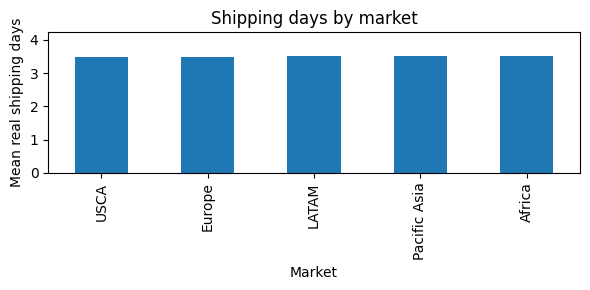

In [9]:
by_market = y.groupby(train["Market"]).mean().sort_values()
fig, ax = plt.subplots(figsize=(6, 3))
by_market.plot.bar(ax=ax)
ax.set_ylabel("Mean real shipping days"); ax.set_title("Shipping days by market"); ax.set_ylim(0, by_market.max() * 1.2)
show(fig, "03_days_by_market")

### 5.3 Customer segment and product category

In [10]:
print(y.groupby(train["Customer Segment"]).agg(["mean", "count"]).round(2), "\n")
top_cat = y.groupby(train["Category Name"]).agg(["mean", "count"]).sort_values("count", ascending=False).head(10)
print("Top 10 categories by rows:\n", top_cat.round(2))

                  mean  count
Customer Segment             
Consumer           3.5  71663
Corporate          3.5  41863
Home Office        3.5  24572 

Top 10 categories by rows:
                       mean  count
Category Name                    
Cleats                3.50  18806
Men's Footwear        3.50  17046
Women's Apparel       3.48  16026
Indoor/Outdoor Games  3.51  14764
Fishing               3.50  13287
Water Sports          3.49  11910
Camping & Hiking      3.50  10520
Cardio Equipment      3.50   9535
Shop By Sport         3.49   8377
Electronics           3.50   2391


## Step 6 – Numeric features vs the target, and correlation
### 6.1 Correlation of each numeric column with the target
**Pearson** measures straight-line relationships; **Spearman** uses ranks, so it also catches curved ones and is less affected by outliers.

In [11]:
num_vs_target = pd.DataFrame({
    "pearson": train[NUMERIC].corrwith(y),
    "spearman": train[NUMERIC].corrwith(y, method="spearman"),
}).sort_values("spearman", key=abs, ascending=False)
num_vs_target.round(3)

,pearson,spearman
Longitude,-0.003,-0.004
Order Item Discount Rate,0.002,0.002
Benefit per order,-0.003,-0.002
Sales per customer,0.001,-0.002
Order Item Quantity,-0.003,-0.002
Sales,0.001,-0.002
Order Item Profit Ratio,-0.003,-0.001
Order Item Discount,0.002,0.001
Product Price,0.002,-0.001
Latitude,-0.001,-0.000


### 6.2 Correlation heatmap
Strongly related inputs (multicollinearity) make linear-model coefficients unstable; trees are much less affected.

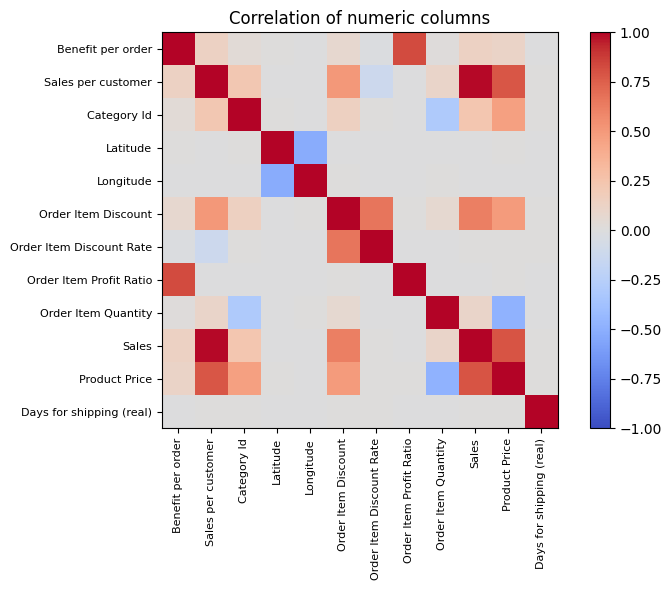

In [12]:
corr = train[NUMERIC + [TARGET]].corr()
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=90, fontsize=8)
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns, fontsize=8)
fig.colorbar(im, ax=ax); ax.set_title("Correlation of numeric columns")
show(fig, "04_correlation_heatmap")

### 6.3 Highly correlated pairs (|r| > 0.9)

In [13]:
pairs = corr.drop(index=TARGET, columns=TARGET).stack()
pairs = pairs[[a < b for a, b in pairs.index]]
high = pairs[pairs.abs() > 0.9].sort_values(key=abs, ascending=False)
print(high.round(3) if len(high) else "none")

Sales  Sales per customer    0.99
dtype: float64


## Step 7 – Outliers, skew and consistency checks
### 7.1 Outlier share and skewness (IQR rule)
A value is an outlier if it lies more than 1.5 × IQR below the 25th or above the 75th percentile.

In [14]:
def iqr_outliers(s):
    q1, q3 = s.quantile([0.25, 0.75]); iqr = q3 - q1
    return ((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).mean() * 100

outliers = pd.DataFrame({
    "outliers_%": [iqr_outliers(train[c]) for c in NUMERIC],
    "skew": [train[c].skew() for c in NUMERIC],
    "min": [train[c].min() for c in NUMERIC],
    "max": [train[c].max() for c in NUMERIC],
}, index=NUMERIC).sort_values("outliers_%", ascending=False)
outliers.round(2)

,outliers_%,skew,min,max
Benefit per order,10.40,-4.43,-4274.98,911.80
Order Item Profit Ratio,9.52,-2.91,-2.75,0.50
Order Item Discount,4.19,3.10,0.00,500.00
Product Price,1.13,3.18,9.99,1999.99
Sales per customer,1.07,2.87,7.49,1939.99
Longitude,0.77,-0.43,-158.03,115.26
Sales,0.27,2.88,9.99,1999.99
Latitude,0.01,-0.10,-33.94,48.78
Category Id,0.00,0.36,2.00,76.00
Order Item Discount Rate,0.00,0.34,0.00,0.25


### 7.2 Boxplot of the financial columns

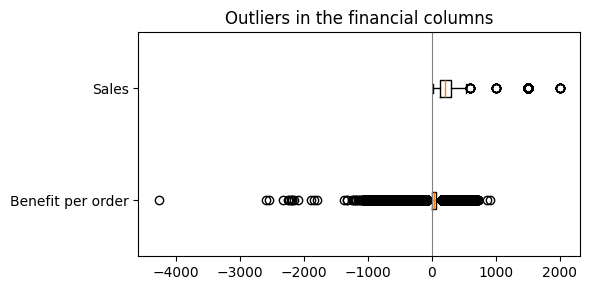

In [15]:
money = [c for c in ["Benefit per order", "Sales"] if c in train.columns]
fig, ax = plt.subplots(figsize=(6, 3))
ax.boxplot([train[c] for c in money], vert=False)
ax.set_yticks(range(1, len(money) + 1)); ax.set_yticklabels(money)
ax.axvline(0, color="grey", lw=0.8); ax.set_title("Outliers in the financial columns")
show(fig, "05_boxplot_financial")

### 7.3 Negative profits – error or real?
Negative profit is a **genuine loss**, not an error (7.4 shows the money columns agree with each other), so these rows are **kept**.

In [16]:
neg = train["Benefit per order"] < 0
print(f"Rows with negative Benefit per order: {neg.mean() * 100:.1f}% (min {train['Benefit per order'].min():,.2f})")
print("Mean shipping days | loss:", round(y[neg].mean(), 3), "| profit:", round(y[~neg].mean(), 3))

Rows with negative Benefit per order: 18.7% (min -4,274.98)
Mean shipping days | loss: 3.508 | profit: 3.498


### 7.4 Consistency checks (invalid records)
Each rule should hold for ~100% of rows (a small tolerance allows for rounding).

In [17]:
price_col = "Product Price" if "Product Price" in train.columns else "Order Item Product Price"
checks = {}
if "Sales" in train.columns:
    checks["Sales = Price x Quantity"] = np.isclose(train["Sales"], train[price_col] * train["Order Item Quantity"], atol=0.05)
    checks["Sales per customer = Sales - Discount"] = np.isclose(train["Sales per customer"], train["Sales"] - train["Order Item Discount"], atol=0.05)
checks["Discount Rate between 0 and 1"] = train["Order Item Discount Rate"].between(0, 1)
pd.Series({k: f"{v.mean() * 100:.2f}% of rows" for k, v in checks.items()}, name="holds for")

Sales = Price x Quantity                 100.00% of rows
Sales per customer = Sales - Discount    100.00% of rows
Discount Rate between 0 and 1            100.00% of rows
Name: holds for, dtype: object

## Step 8 – Time patterns
These charts are the evidence for (or against) the date features created in Step 9.
### 8.1 By order weekday

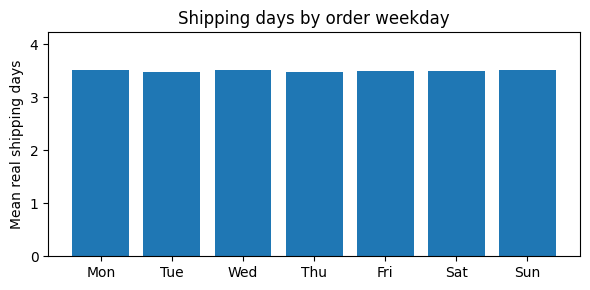

In [18]:
DAYS = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
by_weekday = y.groupby(train["order_dt"].dt.weekday).mean()
fig, ax = plt.subplots(figsize=(6, 3))
ax.bar([DAYS[i] for i in by_weekday.index], by_weekday.values)
ax.set_ylabel("Mean real shipping days"); ax.set_title("Shipping days by order weekday"); ax.set_ylim(0, by_weekday.max() * 1.2)
show(fig, "06_days_by_weekday")

### 8.2 By order hour

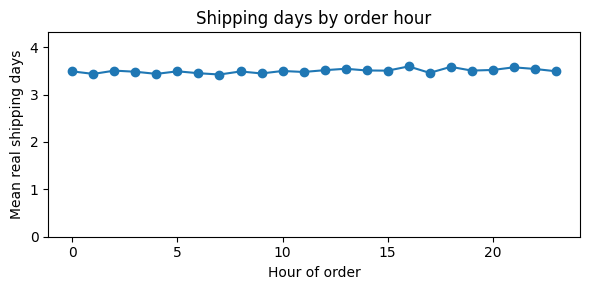

In [19]:
by_hour = y.groupby(train["order_dt"].dt.hour).mean()
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(by_hour.index, by_hour.values, marker="o")
ax.set_xlabel("Hour of order"); ax.set_ylabel("Mean real shipping days"); ax.set_title("Shipping days by order hour")
ax.set_ylim(0, by_hour.max() * 1.2)
show(fig, "07_days_by_hour")

### 8.3 Over time (drift check)
A stable line means behaviour does not drift over 2015–2018, so a grouped random split is acceptable.

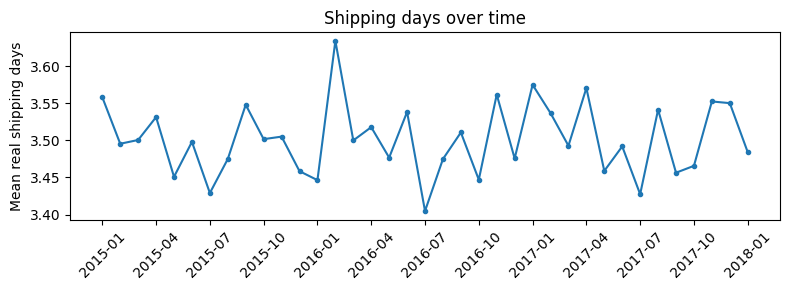

       mean_days   orders
count      37.00    37.00
mean        3.50  1359.95
std         0.05    95.96
min         3.40  1203.00
25%         3.47  1314.00
50%         3.50  1345.00
75%         3.54  1360.00
max         3.63  1630.00


In [20]:
monthly = train.groupby(train["order_dt"].dt.to_period("M")).agg(mean_days=(TARGET, "mean"), orders=(GROUP, "nunique"))
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(monthly.index.astype(str), monthly["mean_days"], marker=".")
ax.set_ylabel("Mean real shipping days"); ax.set_title("Shipping days over time")
ax.set_xticks(range(0, len(monthly), max(1, len(monthly) // 12))); ax.tick_params(axis="x", rotation=45)
show(fig, "08_days_over_time")
print(monthly.describe().round(2))

## Step 9 – Feature engineering: date features
### 9.1 The date-feature function
Five features are made from the order timestamp: **order_weekday** (0 = Monday), **order_month**, **order_hour**, **order_quarter**, **is_weekend**.
Why: dispatch speed may depend on when the order arrives (weekends, busy months, late-day orders).

**No leakage:** each feature uses only that row's own order date, which is known when the order is placed. Nothing is learned
from other rows or from the target, so applying the same function to train and test is safe. The backend will apply the
same function to a new order.

In [21]:
DATE_FEATURES = ["order_weekday", "order_month", "order_hour", "order_quarter", "is_weekend"]

def add_date_features(df):
    out = df.copy()
    d = pd.to_datetime(out[DATE_COL], format=DATE_FMT, errors="coerce")
    out["order_weekday"] = d.dt.weekday
    out["order_month"] = d.dt.month
    out["order_hour"] = d.dt.hour
    out["order_quarter"] = d.dt.quarter
    out["is_weekend"] = (d.dt.weekday >= 5).astype(int)
    return out

train_fe = add_date_features(train.drop(columns=["order_dt"]))
train_fe[[DATE_COL] + DATE_FEATURES].head()

,order date (DateOrders),order_weekday,order_month,order_hour,order_quarter,is_weekend
0,1/31/2018 22:56,2,1,22,1,0
1,1/13/2018 12:27,5,1,12,1,1
2,1/13/2018 11:45,5,1,11,1,1
3,1/13/2018 11:24,5,1,11,1,1
4,1/13/2018 10:42,5,1,10,1,1


### 9.2 Are the date features related to the target?
Eta² for each date feature, compared with Shipping Mode. Small values are likely – weak features are kept for now, M3 checks them with cross-validation.

In [22]:
date_strength = pd.Series({f: eta_squared(train_fe[f], y) for f in DATE_FEATURES + ["Shipping Mode"]}, name="eta_squared")
date_strength.sort_values(ascending=False).round(4).to_frame()

,eta_squared
Shipping Mode,0.3889
order_hour,0.0008
order_month,0.0005
order_quarter,0.0001
order_weekday,0.0001
is_weekend,0.0000


### 9.3 Shipping days by month

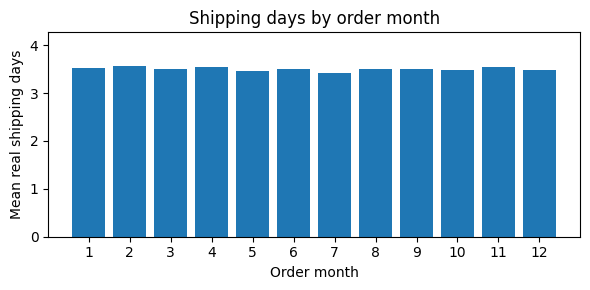

In [23]:
by_month = y.groupby(train_fe["order_month"]).mean()
fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(by_month.index.astype(str), by_month.values)
ax.set_xlabel("Order month"); ax.set_ylabel("Mean real shipping days"); ax.set_title("Shipping days by order month")
ax.set_ylim(0, by_month.max() * 1.2)
show(fig, "09_days_by_month")

## Step 10 – Save the train and test files with date features
The test set is loaded here for the first time and **only** gets the same date features (no exploring, no fitting).

In [24]:
test = pd.read_csv(PROCESSED_DIR / "test_reg.csv")
test_fe = add_date_features(test)

train_fe.to_csv(PROCESSED_DIR / "train_fe.csv", index=False)
test_fe.to_csv(PROCESSED_DIR / "test_fe.csv", index=False)
print("Saved train_fe.csv", train_fe.shape, "and test_fe.csv", test_fe.shape)
print("Missing values in the new features:", int(train_fe[DATE_FEATURES].isna().sum().sum() + test_fe[DATE_FEATURES].isna().sum().sum()))

Saved train_fe.csv (138098, 33) and test_fe.csv (34667, 33)
Missing values in the new features: 0


## Step 11 – Key findings summary

In [25]:
print(f'''
TARGET          mean {y.mean():.2f} days, std {y.std():.2f}, range {y.min()}-{y.max()}, skew {y.skew():.2f}
SHIPPING MODE   eta^2 = {eta_squared(train["Shipping Mode"], y):.3f}  (share of variation explained by mode alone)
TOP CATEGORICAL {", ".join(f"{c} ({v:.3f})" for c, v in cat_strength["eta_squared"].head(3).items())}
TOP NUMERIC     {", ".join(f"{c} ({v:+.3f})" for c, v in num_vs_target["spearman"].head(3).items())}
REDUNDANT PAIRS {len(high)} numeric pairs with |r| > 0.9
OUTLIERS        most: {outliers.index[0]} ({outliers.iloc[0]["outliers_%"]:.1f}% of rows)
NEGATIVE PROFIT {neg.mean() * 100:.1f}% of rows (kept - genuine losses)
MISSING / DUPS  {int(missing.sum())} missing cells, {train.duplicated().sum()} duplicate rows
DATE FEATURES   {", ".join(DATE_FEATURES)}
''')


TARGET          mean 3.50 days, std 1.63, range 0-6, skew 0.09
SHIPPING MODE   eta^2 = 0.389  (share of variation explained by mode alone)
TOP CATEGORICAL Shipping Mode (0.389), Order City (0.096), Order State (0.030)
TOP NUMERIC     Longitude (-0.004), Order Item Discount Rate (+0.002), Benefit per order (-0.002)
REDUNDANT PAIRS 1 numeric pairs with |r| > 0.9
OUTLIERS        most: Benefit per order (10.4% of rows)
NEGATIVE PROFIT 18.7% of rows (kept - genuine losses)
MISSING / DUPS  0 missing cells, 0 duplicate rows
DATE FEATURES   order_weekday, order_month, order_hour, order_quarter, is_weekend



**My contribution in one sentence:** I explored the training data to find which features relate to shipping time,
checked data quality, outliers and time patterns, and created the date features used by the model.